# Task 4: Fund Performance Analytics

# Mission 1: Daily Return Analysis

## Objective

The objective of this mission is to calculate the daily percentage returns of each mutual fund scheme using historical NAV data. Daily returns help measure the day-to-day performance of a fund and serve as the foundation for advanced performance metrics such as Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

In [434]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [435]:
nav_df = pd.read_csv("../Data/Raw/02_nav_history.csv")

In [436]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [437]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [438]:
nav_df.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [439]:
nav_df.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [440]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [441]:
nav_df = nav_df.sort_values(
    by=["amfi_code", "date"]
)

In [442]:
nav_df.head(10)

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639
5755,100016,2022-01-10,510.7136
5756,100016,2022-01-11,513.5542
5757,100016,2022-01-12,512.3195
5758,100016,2022-01-13,510.2445
5759,100016,2022-01-14,514.3636


In [443]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

In [444]:
nav_df.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [445]:
nav_df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

# Mission 2: CAGR (Compound Annual Growth Rate) Analysis

## Objective

The objective of this mission is to calculate the Compound Annual Growth Rate (CAGR) for each mutual fund scheme using historical NAV data. CAGR measures the annualized growth rate of an investment over a specific period by considering the compounding effect.

This mission involves:
- Extracting the first and last NAV values for each mutual fund.
- Calculating the investment duration using the first and last available dates.
- Computing the CAGR using the standard financial formula.
- Building a comparison table across all mutual fund schemes for further performance analysis.

## Additional Analysis: Overall CAGR (Entire Available Period)

In [446]:
cagr_df = nav_df.groupby("amfi_code").agg(
    start_date=("date", "first"),
    end_date=("date", "last"),
    start_nav=("nav", "first"),
    end_nav=("nav", "last")
)

cagr_df.head()

,start_date,end_date,start_nav,end_nav
amfi_code,,,,
100016,2022-01-03,2026-05-29,520.4608,583.6113
100025,2022-01-03,2026-05-29,26.3169,31.8843
100033,2022-01-03,2026-05-29,107.3758,342.0072
101206,2022-01-03,2026-05-29,305.0996,773.2939
101207,2022-01-03,2026-05-29,38.5736,53.9836


In [447]:
cagr_df["years"] = (
    cagr_df["end_date"] - cagr_df["start_date"]
).dt.days / 365.25

cagr_df.head()

,start_date,end_date,start_nav,end_nav,years
amfi_code,,,,,
100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726
100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726
101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726
101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726


In [448]:
cagr_df["cagr"] = (
    (cagr_df["end_nav"] / cagr_df["start_nav"])
    ** (1 / cagr_df["years"])
) - 1

cagr_df.head()

,start_date,end_date,start_nav,end_nav,years,cagr
amfi_code,,,,,,
100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726,0.026371
100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726,0.044582
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232
101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384
101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726,0.079388


In [449]:
cagr_df["cagr_percent"] = cagr_df["cagr"] * 100

cagr_df.head()

,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent
amfi_code,,,,,,,
100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726,0.026371,2.637074
100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726,0.044582,4.458210
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153
101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384,23.538361
101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726,0.079388,7.938765


In [450]:
cagr_df = cagr_df.sort_values(
    by="cagr_percent",
    ascending=False
)

cagr_df.head(10)

,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent
amfi_code,,,,,,,
120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406
119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536
149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440
148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523
148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108
120843,2022-01-03,2026-05-29,49.9131,163.2397,4.399726,0.309075,30.907455
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153
149323,2022-01-03,2026-05-29,78.4622,245.3651,4.399726,0.295811,29.581087
119094,2022-01-03,2026-05-29,68.3023,203.8581,4.399726,0.282144,28.214417


In [451]:
nav_df["amfi_code"].nunique()

40

In [452]:
latest_date = nav_df["date"].max()

latest_date

Timestamp('2026-05-29 00:00:00')

# Mission 2: 1-Year, 3-Year and 5-Year CAGR Analysis

In [453]:
one_year_date = latest_date - pd.DateOffset(years=1)

one_year_date

Timestamp('2025-05-29 00:00:00')

In [454]:
one_year_df = nav_df[
    nav_df["date"] <= one_year_date
]

one_year_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [455]:
one_year_df = nav_df[
    nav_df["date"] <= one_year_date
]

one_year_nav = (
    one_year_df
    .groupby("amfi_code")
    .last()[["date", "nav"]]
)

one_year_nav.head()

,date,nav
amfi_code,,
100016,2025-05-29,596.8877
100025,2025-05-29,30.7452
100033,2025-05-29,223.1951
101206,2025-05-29,522.7639
101207,2025-05-29,71.0180


In [456]:
one_year_nav = one_year_nav.rename(
    columns={
        "date": "one_year_date",
        "nav": "one_year_nav"
    }
)

one_year_nav.head()

,one_year_date,one_year_nav
amfi_code,,
100016,2025-05-29,596.8877
100025,2025-05-29,30.7452
100033,2025-05-29,223.1951
101206,2025-05-29,522.7639
101207,2025-05-29,71.0180


In [457]:
cagr_1yr = cagr_df.merge(
    one_year_nav,
    on="amfi_code",
    how="left"
)

cagr_1yr.head()

,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,one_year_date,one_year_nav
amfi_code,,,,,,,,,
120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,2025-05-29,365.5455
119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,2025-05-29,169.1715
149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,2025-05-29,169.4037
148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,2025-05-29,69.9408
148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,2025-05-29,191.3173


## 1-Year CAGR Analysis

In [458]:
cagr_1yr["cagr_1yr"] = (
    cagr_1yr["end_nav"] / cagr_1yr["one_year_nav"]
) - 1

cagr_1yr.head()

,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,one_year_date,one_year_nav,cagr_1yr
amfi_code,,,,,,,,,,
120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,2025-05-29,365.5455,0.296047
119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,2025-05-29,169.1715,0.827761
149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,2025-05-29,169.4037,0.651387
148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,2025-05-29,69.9408,0.397518
148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,2025-05-29,191.3173,0.203607


In [459]:
cagr_1yr["cagr_1yr_percent"] = cagr_1yr["cagr_1yr"] * 100

cagr_1yr.head()

,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,one_year_date,one_year_nav,cagr_1yr,cagr_1yr_percent
amfi_code,,,,,,,,,,,
120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,2025-05-29,365.5455,0.296047,29.604659
119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,2025-05-29,169.1715,0.827761,82.776059
149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,2025-05-29,169.4037,0.651387,65.138719
148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,2025-05-29,69.9408,0.397518,39.751761
148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,2025-05-29,191.3173,0.203607,20.360678


In [460]:
cagr_1yr = cagr_1yr.sort_values(
    by="cagr_1yr_percent",
    ascending=False
)

cagr_1yr.head(10)

,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,one_year_date,one_year_nav,cagr_1yr,cagr_1yr_percent
amfi_code,,,,,,,,,,,
119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,2025-05-29,169.1715,0.827761,82.776059
149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,2025-05-29,169.4037,0.651387,65.138719
119551,2022-01-03,2026-05-29,54.3856,149.3216,4.399726,0.258047,25.804686,2025-05-29,93.0716,0.604373,60.437341
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153,2025-05-29,223.1951,0.532324,53.232396
101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384,23.538361,2025-05-29,522.7639,0.479241,47.924120
120506,2022-01-03,2026-05-29,202.0453,404.4207,4.399726,0.170849,17.084867,2025-05-29,285.1667,0.418190,41.819048
148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,2025-05-29,69.9408,0.397518,39.751761
118632,2022-01-03,2026-05-29,42.8339,110.5554,4.399726,0.240495,24.049493,2025-05-29,82.5157,0.339810,33.981048
120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,2025-05-29,365.5455,0.296047,29.604659


## 3-Year CAGR Analysis

In [461]:
three_year_date = latest_date - pd.DateOffset(years=3)

three_year_date

Timestamp('2023-05-29 00:00:00')

In [462]:
three_year_df = nav_df[
    nav_df["date"] <= three_year_date
]

three_year_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [463]:
three_year_nav = (
    three_year_df
    .groupby("amfi_code")
    .last()[["date", "nav"]]
)

three_year_nav.head()

,date,nav
amfi_code,,
100016,2023-05-29,561.5519
100025,2023-05-29,28.4135
100033,2023-05-29,147.2155
101206,2023-05-29,360.4971
101207,2023-05-29,61.3081


In [464]:
three_year_nav = three_year_nav.rename(
    columns={
        "date": "three_year_date",
        "nav": "three_year_nav"
    }
)

three_year_nav.head()

,three_year_date,three_year_nav
amfi_code,,
100016,2023-05-29,561.5519
100025,2023-05-29,28.4135
100033,2023-05-29,147.2155
101206,2023-05-29,360.4971
101207,2023-05-29,61.3081


In [465]:
cagr_3yr = cagr_df.merge(
    three_year_nav,
    on="amfi_code",
    how="left"
)

cagr_3yr.head()

,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,three_year_date,three_year_nav
amfi_code,,,,,,,,,
120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,2023-05-29,207.0322
119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,2023-05-29,152.1339
149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,2023-05-29,136.5703
148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,2023-05-29,45.3433
148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,2023-05-29,95.7008


In [466]:
cagr_3yr["cagr_3yr"] = (
    (cagr_3yr["end_nav"] / cagr_3yr["three_year_nav"])
    ** (1 / 3)
) - 1

cagr_3yr.head()

,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,three_year_date,three_year_nav,cagr_3yr
amfi_code,,,,,,,,,,
120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,2023-05-29,207.0322,0.317775
119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,2023-05-29,152.1339,0.266699
149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,2023-05-29,136.5703,0.270004
148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,2023-05-29,45.3433,0.291789
148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,2023-05-29,95.7008,0.340009


In [467]:
cagr_3yr["cagr_3yr_percent"] = cagr_3yr["cagr_3yr"] * 100

cagr_3yr.head()

,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,three_year_date,three_year_nav,cagr_3yr,cagr_3yr_percent
amfi_code,,,,,,,,,,,
120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,2023-05-29,207.0322,0.317775,31.777537
119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,2023-05-29,152.1339,0.266699,26.669922
149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,2023-05-29,136.5703,0.270004,27.000427
148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,2023-05-29,45.3433,0.291789,29.178902
148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,2023-05-29,95.7008,0.340009,34.000916


In [468]:
cagr_3yr = cagr_3yr.sort_values(
    by="cagr_3yr_percent",
    ascending=False
)

cagr_3yr.head(10)

,start_date,end_date,start_nav,end_nav,years,cagr,cagr_percent,three_year_date,three_year_nav,cagr_3yr,cagr_3yr_percent
amfi_code,,,,,,,,,,,
119094,2022-01-03,2026-05-29,68.3023,203.8581,4.399726,0.282144,28.214417,2023-05-29,82.6510,0.351118,35.111802
148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,2023-05-29,95.7008,0.340009,34.000916
120504,2022-01-03,2026-05-29,60.1474,151.1311,4.399726,0.232951,23.295119,2023-05-29,64.9875,0.324874,32.487429
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153,2023-05-29,147.2155,0.324425,32.442459
120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,2023-05-29,207.0322,0.317775,31.777537
119551,2022-01-03,2026-05-29,54.3856,149.3216,4.399726,0.258047,25.804686,2023-05-29,67.2551,0.304565,30.456524
120843,2022-01-03,2026-05-29,49.9131,163.2397,4.399726,0.309075,30.907455,2023-05-29,75.0212,0.295828,29.582770
148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,2023-05-29,45.3433,0.291789,29.178902
101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384,23.538361,2023-05-29,360.4971,0.289677,28.967695


## 5-Year CAGR Analysis

In [469]:
five_year_date = latest_date - pd.DateOffset(years=5)

five_year_date

Timestamp('2021-05-29 00:00:00')

In [470]:
earliest_date = nav_df["date"].min()

earliest_date

Timestamp('2022-01-03 00:00:00')

In [471]:
five_year_date = latest_date - pd.DateOffset(years=5)

earliest_date = nav_df["date"].min()

if five_year_date < earliest_date:
    print("5-Year CAGR cannot be calculated.")
    print("Insufficient historical data.")
else:
    print("5-Year CAGR can be calculated.")

5-Year CAGR cannot be calculated.
Insufficient historical data.


## Comparison table across all funds.

In [472]:
cagr_1yr_table = cagr_1yr[["cagr_1yr_percent"]]

In [473]:
cagr_3yr_table = cagr_3yr[["cagr_3yr_percent"]]

In [474]:
comparison_df = cagr_1yr_table.join(cagr_3yr_table)

In [475]:
comparison_df.head()

,cagr_1yr_percent,cagr_3yr_percent
amfi_code,,
119598,82.776059,26.669922
149324,65.138719,27.000427
119551,60.437341,30.456524
100033,53.232396,32.442459
101206,47.924120,28.967695


In [476]:
comparison_df["cagr_5yr_percent"] = np.nan

In [477]:
comparison_df.head(10)

,cagr_1yr_percent,cagr_3yr_percent,cagr_5yr_percent
amfi_code,,,
119598,82.776059,26.669922,NaN
149324,65.138719,27.000427,NaN
119551,60.437341,30.456524,NaN
100033,53.232396,32.442459,NaN
101206,47.924120,28.967695,NaN
120506,41.819048,18.421997,NaN
148569,39.751761,29.178902,NaN
118632,33.981048,22.652360,NaN
120505,29.604659,31.777537,NaN


In [478]:
comparison_df = comparison_df.round(2)

comparison_df.head(10)

,cagr_1yr_percent,cagr_3yr_percent,cagr_5yr_percent
amfi_code,,,
119598,82.78,26.67,NaN
149324,65.14,27.00,NaN
119551,60.44,30.46,NaN
100033,53.23,32.44,NaN
101206,47.92,28.97,NaN
120506,41.82,18.42,NaN
148569,39.75,29.18,NaN
118632,33.98,22.65,NaN
120505,29.60,31.78,NaN


In [479]:
comparison_df = comparison_df.rename(
    columns={
        "cagr_1yr_percent": "CAGR_1Y (%)",
        "cagr_3yr_percent": "CAGR_3Y (%)",
        "cagr_5yr_percent": "CAGR_5Y (%)"
    }
)

comparison_df.head(10)

,CAGR_1Y (%),CAGR_3Y (%),CAGR_5Y (%)
amfi_code,,,
119598,82.78,26.67,NaN
149324,65.14,27.00,NaN
119551,60.44,30.46,NaN
100033,53.23,32.44,NaN
101206,47.92,28.97,NaN
120506,41.82,18.42,NaN
148569,39.75,29.18,NaN
118632,33.98,22.65,NaN
120505,29.60,31.78,NaN


In [480]:
comparison_df = comparison_df.sort_index()
comparison_df.head(10)

,CAGR_1Y (%),CAGR_3Y (%),CAGR_5Y (%)
amfi_code,,,
100016,-2.22,1.29,NaN
100025,3.70,3.92,NaN
100033,53.23,32.44,NaN
101206,47.92,28.97,NaN
101207,-23.99,-4.15,NaN
101208,7.24,6.32,NaN
102885,20.21,19.67,NaN
102886,-16.80,-0.77,NaN
102887,13.58,25.56,NaN


# Mission 3: Sharpe Ratio Analysis

## Objective

The objective of this mission is to evaluate the risk-adjusted performance of each mutual fund scheme using the Sharpe Ratio.

The Sharpe Ratio measures how much excess return a fund generates for each unit of risk taken.

Formula:

Sharpe Ratio = (Rp − Rf) / Std(Rp) × √252

Where:
- Rp = Average Daily Return
- Rf = Risk-Free Rate (6.5% per annum)
- Std(Rp) = Standard Deviation of Daily Returns
- √252 = Annualization factor (252 trading days)

The funds will be ranked based on their Sharpe Ratio to identify the best risk-adjusted performers.

In [481]:
sharpe_df = nav_df.groupby("amfi_code").agg(
    avg_daily_return=("daily_return", "mean")
)

sharpe_df.head()

,avg_daily_return
amfi_code,
100016,0.000142
100025,0.000170
100033,0.001080
101206,0.000852
101207,0.000424


In [482]:
sharpe_df["std_daily_return"] = (
    nav_df.groupby("amfi_code")["daily_return"]
    .std()
)

sharpe_df.head()

,avg_daily_return,std_daily_return
amfi_code,,
100016,0.000142,0.009164
100025,0.000170,0.002460
100033,0.001080,0.011929
101206,0.000852,0.009177
101207,0.000424,0.016251


In [483]:
risk_free_rate = 0.065 / 252

In [484]:
sharpe_df["sharpe_ratio"] = (
    (sharpe_df["avg_daily_return"] - risk_free_rate)
    / sharpe_df["std_daily_return"]
) * np.sqrt(252)

sharpe_df.head()

,avg_daily_return,std_daily_return,sharpe_ratio
amfi_code,,,
100016,0.000142,0.009164,-0.201517
100025,0.000170,0.002460,-0.567095
100033,0.001080,0.011929,1.093699
101206,0.000852,0.009177,1.027213
101207,0.000424,0.016251,0.162661


In [485]:
sharpe_df = sharpe_df.sort_values(
    by="sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,avg_daily_return,std_daily_return,sharpe_ratio
amfi_code,,,
148567,0.001074,0.008941,1.448291
120843,0.001082,0.010008,1.306744
148569,0.001124,0.011134,1.234930
119551,0.000917,0.008656,1.208267
120505,0.001161,0.012152,1.180101
149323,0.001055,0.011179,1.132122
100033,0.001080,0.011929,1.093699
118632,0.000865,0.008913,1.081659
101206,0.000852,0.009177,1.027213


# Mission 4: Sortino Ratio Analysis

## Objective

Calculate the Sortino Ratio for all mutual funds using downside standard deviation (negative return days only) and rank the funds based on their risk-adjusted performance.

In [486]:
negative_returns = nav_df[
    nav_df["daily_return"] < 0
]

negative_returns.head()

,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5757,100016,2022-01-12,512.3195,-0.002404


In [487]:
sortino_df = sharpe_df.copy()

sortino_df.head()

,avg_daily_return,std_daily_return,sharpe_ratio
amfi_code,,,
148567,0.001074,0.008941,1.448291
120843,0.001082,0.010008,1.306744
148569,0.001124,0.011134,1.234930
119551,0.000917,0.008656,1.208267
120505,0.001161,0.012152,1.180101


In [488]:
sortino_df["downside_std"] = (
    negative_returns
    .groupby("amfi_code")["daily_return"]
    .std()
)

sortino_df.head()

,avg_daily_return,std_daily_return,sharpe_ratio,downside_std
amfi_code,,,,
148567,0.001074,0.008941,1.448291,0.005428
120843,0.001082,0.010008,1.306744,0.005531
148569,0.001124,0.011134,1.234930,0.006404
119551,0.000917,0.008656,1.208267,0.004887
120505,0.001161,0.012152,1.180101,0.007067


In [489]:
sortino_df["sortino_ratio"] = (
    (sortino_df["avg_daily_return"] - risk_free_rate)
    / sortino_df["downside_std"]
) * np.sqrt(252)

sortino_df.head()

,avg_daily_return,std_daily_return,sharpe_ratio,downside_std,sortino_ratio
amfi_code,,,,,
148567,0.001074,0.008941,1.448291,0.005428,2.385644
120843,0.001082,0.010008,1.306744,0.005531,2.364320
148569,0.001124,0.011134,1.234930,0.006404,2.146914
119551,0.000917,0.008656,1.208267,0.004887,2.140267
120505,0.001161,0.012152,1.180101,0.007067,2.029353


In [490]:
sortino_df = sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,avg_daily_return,std_daily_return,sharpe_ratio,downside_std,sortino_ratio
amfi_code,,,,,
148567,0.001074,0.008941,1.448291,0.005428,2.385644
120843,0.001082,0.010008,1.306744,0.005531,2.364320
148569,0.001124,0.011134,1.234930,0.006404,2.146914
119551,0.000917,0.008656,1.208267,0.004887,2.140267
120505,0.001161,0.012152,1.180101,0.007067,2.029353
149323,0.001055,0.011179,1.132122,0.006750,1.875101
118632,0.000865,0.008913,1.081659,0.005211,1.850133
100033,0.001080,0.011929,1.093699,0.007133,1.829134
120504,0.000843,0.009048,1.026524,0.005145,1.805294


# Mission 5: Alpha and Beta Analysis

## Objective

Calculate Alpha and Beta for each mutual fund using linear regression against the Nifty 100 benchmark returns.

In [491]:
import os

os.getcwd()


'c:\\Users\\HP\\OneDrive\\Desktop\\Bluestock fintech Internship\\Mutual_Fund_Analytics\\Notebooks'

In [492]:
benchmark_df = pd.read_csv("../Data/Raw/10_benchmark_indices.csv")

benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [493]:
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [494]:
benchmark_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


In [495]:
benchmark_df.describe()

,close_value
count,8050.000000
mean,18351.950181
std,14169.995121
min,1444.130000
25%,2819.062500
50%,18392.960000
75%,26539.097500
max,79075.390000


In [496]:
benchmark_df.isnull().sum()

date           0
index_name     0
close_value    0
dtype: int64

In [497]:
benchmark_df["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [498]:
benchmark_nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
]

benchmark_nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [499]:
benchmark_nifty100["date"] = pd.to_datetime(
    benchmark_nifty100["date"]
)

benchmark_nifty100.info()

<class 'pandas.DataFrame'>
RangeIndex: 1150 entries, 1150 to 2299
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1150 non-null   datetime64[us]
 1   index_name   1150 non-null   str           
 2   close_value  1150 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 27.1 KB


In [500]:
benchmark_nifty100 = benchmark_nifty100.sort_values(
    by="date"
)

benchmark_nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [501]:
benchmark_nifty100["benchmark_return"] = (
    benchmark_nifty100["close_value"]
    .pct_change()
)

benchmark_nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


## Merge Mutual Fund Returns with Benchmark Returns

In [502]:
merged_df = nav_df.merge(
    benchmark_nifty100[["date", "benchmark_return"]],
    on="date",
    how="left"
)

merged_df.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


## Calculate Alpha and Beta using Linear Regression

In [503]:
from scipy.stats import linregress

In [504]:
alpha_beta_results = []

In [505]:
for amfi_code in merged_df["amfi_code"].unique():
    print(amfi_code)

100016
100025
100033
101206
101207
101208
102885
102886
102887
118632
118633
118634
118635
118636
119092
119093
119094
119095
119120
119551
119552
119598
119599
120503
120504
120505
120506
120507
120841
120842
120843
120844
125497
125498
148567
148568
148569
149322
149323
149324


In [506]:
for amfi_code in merged_df["amfi_code"].unique():

    fund_data = merged_df[
        merged_df["amfi_code"] == amfi_code
    ]

    print(fund_data.head())
    break

   amfi_code       date       nav  daily_return  benchmark_return
0     100016 2022-01-03  520.4608           NaN               NaN
1     100016 2022-01-04  515.0971     -0.010306         -0.013540
2     100016 2022-01-05  521.7239      0.012865          0.004003
3     100016 2022-01-06  515.7880     -0.011377         -0.002935
4     100016 2022-01-07  515.1639     -0.001210          0.006150


### Remove Missing Values

In [507]:
fund_data = fund_data.dropna(
    subset=["daily_return", "benchmark_return"]
)

fund_data.head()

,amfi_code,date,nav,daily_return,benchmark_return
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150
5,100016,2022-01-10,510.7136,-0.008639,-0.008351


### Run Linear Regression


In [508]:
slope, intercept, r_value, p_value, std_err = linregress(
    fund_data["benchmark_return"],
    fund_data["daily_return"]
)

print("Beta :", slope)
print("Daily Alpha :", intercept)
print("Annual Alpha :", intercept * 252)
print("R-value :", r_value)

Beta : -0.05826843143880891
Daily Alpha : 0.00014871352235886037
Annual Alpha : 0.03747580763443281
R-value : -0.05162395469288772


### Calculate Alpha and Beta for All Mutual Funds

In [509]:
alpha_beta_results = []

for amfi_code in merged_df["amfi_code"].unique():

    fund_data = merged_df[
        merged_df["amfi_code"] == amfi_code
    ]

    fund_data = fund_data.dropna(
        subset=["daily_return", "benchmark_return"]
    )

    slope, intercept, r_value, p_value, std_err = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "beta": slope,
        "alpha": intercept * 252
    })

### Create Alpha and Beta Comparison Table

In [510]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,beta,alpha
0,100016,-0.058268,0.037476
1,100025,0.001158,0.042818
2,100033,0.005104,0.271954
3,101206,0.021086,0.213998
4,101207,-0.065289,0.108971


In [511]:
alpha_beta_df = (
    alpha_beta_df
    .sort_values(by="alpha", ascending=False)
    .reset_index(drop=True)
)

alpha_beta_df.head(10)

,amfi_code,beta,alpha
0,119598,-0.023196,0.303370
1,149324,0.011455,0.300579
2,120505,0.000549,0.292636
3,148569,0.018134,0.282704
4,120843,-0.022830,0.273305
5,100033,0.005104,0.271954
6,148567,0.023684,0.269838
7,149323,-0.002523,0.265986
8,119094,-0.066265,0.260767
9,119551,-0.031751,0.232010


In [512]:
alpha_beta_df.to_csv(
    "../Data/Clean/alpha_beta.csv",
    index=False
)

# Objective

### Calculate the Maximum Drawdown for each mutual fund and identify the worst drawdown period.

### Calculate Running Maximum

In [513]:
nav_df["running_max"] = (
    nav_df
    .groupby("amfi_code")["nav"]
    .cummax()
)

nav_df.head()

,amfi_code,date,nav,daily_return,running_max
5750,100016,2022-01-03,520.4608,NaN,520.4608
5751,100016,2022-01-04,515.0971,-0.010306,520.4608
5752,100016,2022-01-05,521.7239,0.012865,521.7239
5753,100016,2022-01-06,515.7880,-0.011377,521.7239
5754,100016,2022-01-07,515.1639,-0.001210,521.7239


### Calculate Drawdown

In [514]:
nav_df["drawdown"] = (
    nav_df["nav"] / nav_df["running_max"]
) - 1

nav_df.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
5750,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
5751,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
5753,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


### Calculate Maximum Drawdown

In [515]:
max_drawdown_df = nav_df.groupby("amfi_code").agg(
    max_drawdown=("drawdown", "min")
)

max_drawdown_df.head()

,max_drawdown
amfi_code,
100016,-0.247344
100025,-0.043083
100033,-0.162172
101206,-0.112916
101207,-0.354469


### Rank Funds by Maximum Drawdown

In [516]:
max_drawdown_df = (
    max_drawdown_df
    .sort_values(by="max_drawdown", ascending=True)
    .reset_index()
)

max_drawdown_df.head(10)

,amfi_code,max_drawdown
0,119599,-0.525742
1,119095,-0.516778
2,101207,-0.354469
3,149324,-0.311719
4,119598,-0.287060
5,102886,-0.280011
6,100016,-0.247344
7,120842,-0.240035
8,118634,-0.233449
9,119093,-0.217514


### Find Worst Drawdown Date for One Fund

In [517]:
fund_data = nav_df[
    nav_df["amfi_code"] == 100016
]

fund_data.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
5750,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
5751,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
5753,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [518]:
worst_idx = fund_data["drawdown"].idxmin()

print(worst_idx)

5933


In [519]:
worst_idx = fund_data["drawdown"].idxmin()

worst_row = fund_data.loc[worst_idx]

worst_row

amfi_code                    100016
date            2022-09-15 00:00:00
nav                        411.1759
daily_return              -0.019696
running_max                546.3002
drawdown                  -0.247344
Name: 5933, dtype: object

### Find Peak Date

In [520]:
peak_row = fund_data[
    fund_data["nav"] == worst_row["running_max"]
]

peak_row

,amfi_code,date,nav,daily_return,running_max,drawdown
5812,100016,2022-03-30,546.3002,0.00245,546.3002,0.0


## Objective

### Create a composite Fund Scorecard by combining multiple performance metrics and rank all mutual funds.

In [521]:
scheme_performance_df = pd.read_csv(
    "../Data/Processed/07_scheme_performance_clean.csv"
)

scheme_performance_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


### Calculate 3-Year Return Rank

In [523]:
scheme_performance_df["return_3yr_rank"] = (
    scheme_performance_df["return_3yr_pct"]
    .rank(ascending=False, method="min")
)

scheme_performance_df[
    ["scheme_name", "return_3yr_pct", "return_3yr_rank"]
].head()

,scheme_name,return_3yr_pct,return_3yr_rank
0,SBI Bluechip Fund - Regular Plan - Growth,12.36,26.0
1,SBI Bluechip Fund - Direct Plan - Growth,11.30,34.0
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.0
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,2.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,38.0


### Calculate Sharpe Ratio Rank

In [524]:
scheme_performance_df["sharpe_rank"] = (
    scheme_performance_df["sharpe_ratio"]
    .rank(ascending=False, method="min")
)

scheme_performance_df[
    ["scheme_name", "sharpe_ratio", "sharpe_rank"]
].head()

,scheme_name,sharpe_ratio,sharpe_rank
0,SBI Bluechip Fund - Regular Plan - Growth,0.88,26.0
1,SBI Bluechip Fund - Direct Plan - Growth,0.81,35.0
2,SBI Small Cap Fund - Regular Plan - Growth,0.94,18.0
3,SBI Small Cap Fund - Direct Plan - Growth,0.93,19.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,5.0


### Calculate Alpha Rank

In [525]:
scheme_performance_df["alpha_rank"] = (
    scheme_performance_df["alpha"]
    .rank(ascending=False, method="min")
)

scheme_performance_df[
    ["scheme_name", "alpha", "alpha_rank"]
].head()

,scheme_name,alpha,alpha_rank
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,32.0
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,9.0
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,20.0
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,22.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,13.0


### Calculate Expense Ratio Rank

In [526]:
scheme_performance_df["expense_rank"] = (
    scheme_performance_df["expense_ratio_pct"]
    .rank(ascending=True, method="min")
)

scheme_performance_df[
    ["scheme_name", "expense_ratio_pct", "expense_rank"]
].head()

,scheme_name,expense_ratio_pct,expense_rank
0,SBI Bluechip Fund - Regular Plan - Growth,1.54,30.0
1,SBI Bluechip Fund - Direct Plan - Growth,0.66,4.0
2,SBI Small Cap Fund - Regular Plan - Growth,1.43,21.0
3,SBI Small Cap Fund - Direct Plan - Growth,0.72,5.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,9.0


### Calculate Maximum Drawdown Rank

In [527]:
scheme_performance_df["max_drawdown_rank"] = (
    scheme_performance_df["max_drawdown_pct"]
    .rank(ascending=False, method="min")
)

scheme_performance_df[
    ["scheme_name", "max_drawdown_pct", "max_drawdown_rank"]
].head()

,scheme_name,max_drawdown_pct,max_drawdown_rank
0,SBI Bluechip Fund - Regular Plan - Growth,-21.70,21.0
1,SBI Bluechip Fund - Direct Plan - Growth,-24.43,29.0
2,SBI Small Cap Fund - Regular Plan - Growth,-13.35,8.0
3,SBI Small Cap Fund - Direct Plan - Growth,-24.78,30.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-2.30,2.0


### Calculate Fund Score

In [528]:
scheme_performance_df["fund_score"] = (
    scheme_performance_df["return_3yr_rank"] * 0.30 +
    scheme_performance_df["sharpe_rank"] * 0.25 +
    scheme_performance_df["alpha_rank"] * 0.20 +
    scheme_performance_df["expense_rank"] * 0.15 +
    scheme_performance_df["max_drawdown_rank"] * 0.10
)

scheme_performance_df[
    [
        "scheme_name",
        "fund_score"
    ]
].head()

,scheme_name,fund_score
0,SBI Bluechip Fund - Regular Plan - Growth,27.30
1,SBI Bluechip Fund - Direct Plan - Growth,24.25
2,SBI Small Cap Fund - Regular Plan - Growth,12.75
3,SBI Small Cap Fund - Direct Plan - Growth,13.50
4,SBI Magnum Gilt Fund - Regular Plan - Growth,16.80


### Rank Funds by Final Score

In [529]:
scheme_performance_df = (
    scheme_performance_df
    .sort_values(by="fund_score", ascending=True)
    .reset_index(drop=True)
)

scheme_performance_df[
    ["scheme_name", "fund_score"]
].head(10)

,scheme_name,fund_score
0,Kotak Flexicap Fund - Regular - Growth,11.95
1,ICICI Pru Liquid Fund - Regular - Growth,12.70
2,SBI Small Cap Fund - Regular Plan - Growth,12.75
3,HDFC Short Term Debt Fund - Regular - Growth,12.90
4,Kotak Emerging Equity Fund - Regular - Growth,13.45
5,SBI Small Cap Fund - Direct Plan - Growth,13.50
6,Mirae Asset Large Cap Fund - Regular - Growth,14.20
7,ABSL Small Cap Fund - Regular - Growth,14.80
8,Kotak Liquid Fund - Regular - Growth,15.35
9,UTI Flexi Cap Fund - Regular - Growth,15.55


# Mission 8: Benchmark Comparison & Tracking Error Analysis
## Objective

Compare the performance of the Top 5 Mutual Funds against the NIFTY 50 and NIFTY 100 benchmarks over the last 3 years and calculate the Tracking Error for each fund.

### Select Top 5 Funds

In [530]:
top5_funds = scheme_performance_df.head(5)

top5_funds[
    ["amfi_code", "scheme_name", "fund_score"]
]

,amfi_code,scheme_name,fund_score
0,120843,Kotak Flexicap Fund - Regular - Growth,11.95
1,120507,ICICI Pru Liquid Fund - Regular - Growth,12.70
2,119598,SBI Small Cap Fund - Regular Plan - Growth,12.75
3,100025,HDFC Short Term Debt Fund - Regular - Growth,12.90
4,120842,Kotak Emerging Equity Fund - Regular - Growth,13.45


### Filter NAV History for Top 5 Funds

In [531]:
top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_funds["amfi_code"])
]

top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
10350,100025,2022-01-03,26.3169,NaN,26.3169,0.000000
10351,100025,2022-01-04,26.2234,-0.003553,26.3169,-0.003553
10352,100025,2022-01-05,26.2221,-0.000050,26.3169,-0.003602
10353,100025,2022-01-06,26.1728,-0.001880,26.3169,-0.005476
10354,100025,2022-01-07,26.2261,0.002036,26.3169,-0.003450


### Prepare Benchmark Data

In [ ]:
benchmark_nifty50 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

benchmark_nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

In [533]:
benchmark_nifty50["benchmark_return"] = (
    benchmark_nifty50["close_value"].pct_change()
)

benchmark_nifty100["benchmark_return"] = (
    benchmark_nifty100["close_value"].pct_change()
)

In [534]:
benchmark_nifty50.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [535]:
benchmark_nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


### Merge Fund Returns with Benchmark Returns

In [541]:
top5_merged = top5_nav.merge(
    benchmark_nifty100[["date", "benchmark_return"]],
    on="date",
    how="left"
)

top5_merged.head()

,amfi_code,date,nav,daily_return,running_max,drawdown,benchmark_return
0,100025,2022-01-03,26.3169,NaN,26.3169,0.000000,NaN
1,100025,2022-01-04,26.2234,-0.003553,26.3169,-0.003553,-0.013540
2,100025,2022-01-05,26.2221,-0.000050,26.3169,-0.003602,0.004003
3,100025,2022-01-06,26.1728,-0.001880,26.3169,-0.005476,-0.002935
4,100025,2022-01-07,26.2261,0.002036,26.3169,-0.003450,0.006150


In [542]:
print(nav_df["date"].min())
print(nav_df["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


### Filter Last 3 Years of Data

In [543]:
last_date = top5_nav["date"].max()

start_date = last_date - pd.DateOffset(years=3)

top5_nav_3yr = top5_nav[
    top5_nav["date"] >= start_date
]

benchmark_nifty50_3yr = benchmark_nifty50[
    benchmark_nifty50["date"] >= start_date
]

benchmark_nifty100_3yr = benchmark_nifty100[
    benchmark_nifty100["date"] >= start_date
]

print(start_date)
print(last_date)

2023-05-29 00:00:00
2026-05-29 00:00:00


In [544]:
top5_merged = top5_nav_3yr.merge(
    benchmark_nifty100_3yr[
        ["date", "benchmark_return"]
    ],
    on="date",
    how="left"
)

In [545]:
tracking_error_df = (
    top5_merged
    .dropna(subset=["daily_return", "benchmark_return"])
    .assign(
        active_return=lambda df:
        df["daily_return"] - df["benchmark_return"]
    )
    .groupby("amfi_code")
    .agg(
        tracking_error=(
            "active_return",
            lambda x: x.std() * np.sqrt(252)
        )
    )
    .reset_index()
)

tracking_error_df

,amfi_code,tracking_error
0,100025,0.133607
1,119598,0.286772
2,120507,0.127842
3,120842,0.220315
4,120843,0.206410


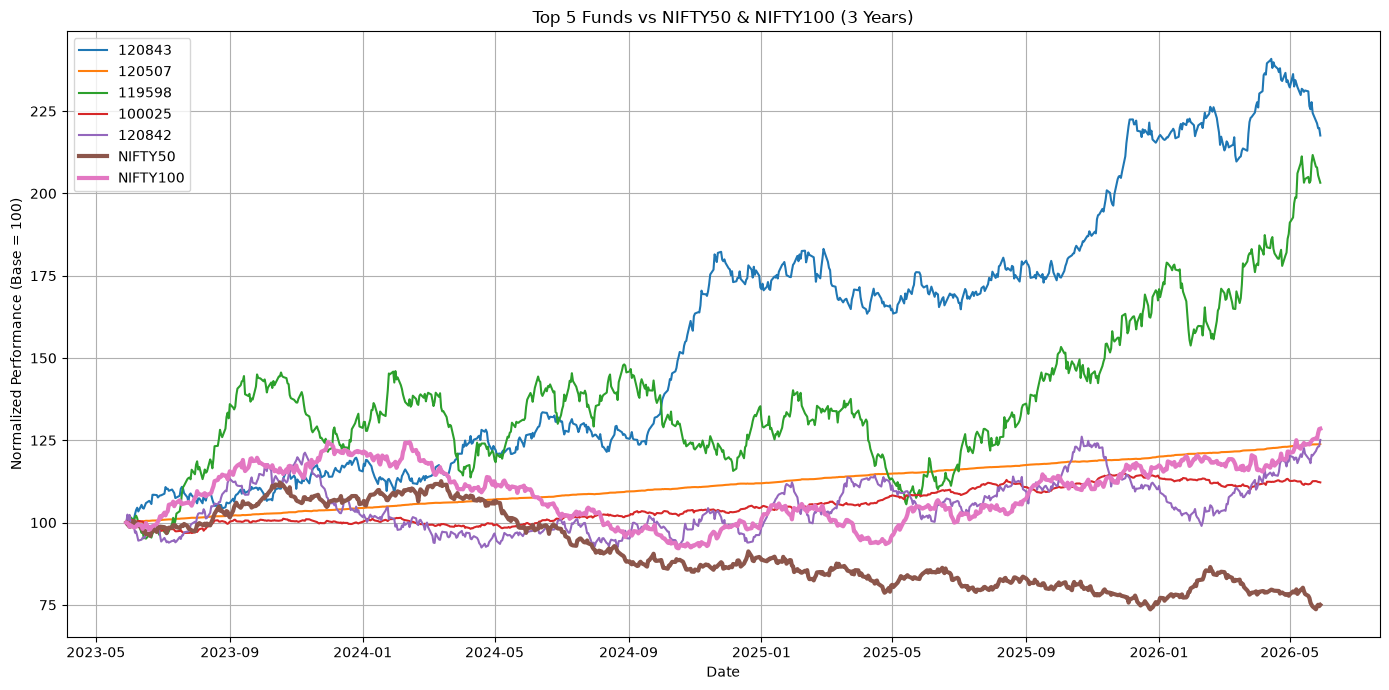

In [546]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

# Top 5 Funds
for code in top5_funds["amfi_code"]:

    fund = top5_nav_3yr[
        top5_nav_3yr["amfi_code"] == code
    ].copy()

    fund["normalized"] = (
        fund["nav"] /
        fund["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund["date"],
        fund["normalized"],
        label=str(code)
    )

# NIFTY50
benchmark_nifty50_3yr = benchmark_nifty50_3yr.copy()

benchmark_nifty50_3yr["normalized"] = (
    benchmark_nifty50_3yr["close_value"] /
    benchmark_nifty50_3yr["close_value"].iloc[0]
) * 100

plt.plot(
    benchmark_nifty50_3yr["date"],
    benchmark_nifty50_3yr["normalized"],
    linewidth=3,
    label="NIFTY50"
)

# NIFTY100
benchmark_nifty100_3yr = benchmark_nifty100_3yr.copy()

benchmark_nifty100_3yr["normalized"] = (
    benchmark_nifty100_3yr["close_value"] /
    benchmark_nifty100_3yr["close_value"].iloc[0]
) * 100

plt.plot(
    benchmark_nifty100_3yr["date"],
    benchmark_nifty100_3yr["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Performance (Base = 100)")
plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../Data/Clean/benchmark_comparison_chart.png",
    dpi=300
)

plt.show()

In [547]:
tracking_error_df.to_csv(
    "../Data/Clean/tracking_error.csv",
    index=False
)